# 01 · One Split

A decision tree is nothing more than *the best single yes/no question*, asked again and again. Here we build that first question **by hand** on two blobs: try every candidate threshold on every feature, score each by how much purer it makes the two groups, and keep the best. "Best split" is a well-defined search, not a mystery.

**Artifacts:** figures → `outputs/figures/01_*.png`, numbers → `outputs/data/01_*.json`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_settings
from src.datasets import two_blobs
from src.tree.criteria import information_gain
from src.tree.splitter import best_split
from src.tree.classifier import DecisionTreeClassifier
from src.evaluation import accuracy, plot_decision_boundary
from src.outputs import save_figure, save_json

SEED = load_settings().seed
RES = 220
X, y = two_blobs(n_samples=200, seed=SEED)
print('X:', X.shape, '| class counts:', np.bincount(y))

X: (200, 2) | class counts: [100 100]


## The data — two blobs
Two Gaussian clusters. One straight cut should separate most of them.

PosixPath('/workspaces/decision_trees_101/outputs/figures/01_two_blobs.png')

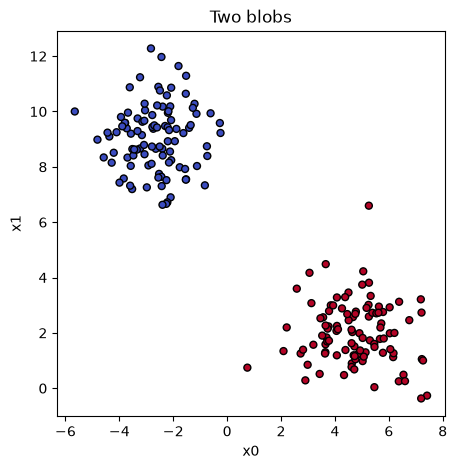

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=25)
ax.set(title='Two blobs', xlabel='x0', ylabel='x1')
save_figure(fig, '01_two_blobs')

## Score every candidate split by hand
For a feature, the candidate thresholds are the midpoints between sorted values. We score each by **information gain** = impurity(parent) − weighted impurity(children), using Gini.

In [3]:
def scan_feature(X, y, f):
    xs = np.unique(X[:, f])
    thresholds = (xs[:-1] + xs[1:]) / 2
    gains = np.array([information_gain(y, X[:, f] <= t, 'gini') for t in thresholds])
    return thresholds, gains

scans = {f: scan_feature(X, y, f) for f in range(X.shape[1])}
best_per_feature = {
    f: {'threshold': float(t[np.argmax(g)]), 'gain': float(g.max())}
    for f, (t, g) in scans.items()
}
best_feature = max(best_per_feature, key=lambda f: best_per_feature[f]['gain'])
best = best_per_feature[best_feature]
print('best feature x%d at threshold %.3f (gain %.3f)' % (best_feature, best['threshold'], best['gain']))

best feature x0 at threshold 0.252 (gain 0.500)


PosixPath('/workspaces/decision_trees_101/outputs/figures/01_gain_vs_threshold.png')

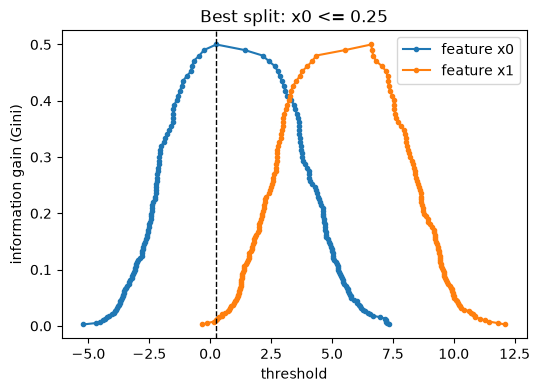

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for f, (t, g) in scans.items():
    ax.plot(t, g, marker='.', label=f'feature x{f}')
ax.axvline(best['threshold'], color='k', ls='--', lw=1)
ax.set(xlabel='threshold', ylabel='information gain (Gini)',
       title=f'Best split: x{best_feature} <= {best["threshold"]:.2f}')
ax.legend()
save_figure(fig, '01_gain_vs_threshold')

## Cross-check against the library splitter, then draw the one-split boundary

hand-picked : 0 0.2523
splitter    : 0 0.2523 | gain 0.5


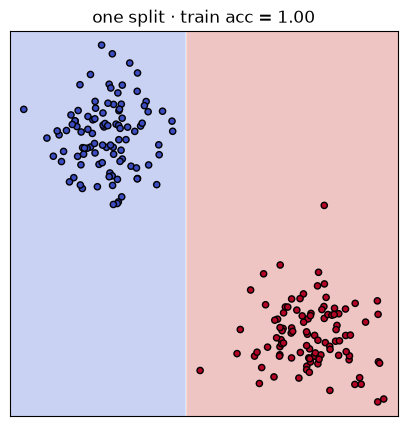

In [5]:
split = best_split(X, y, criterion='gini')
stump = DecisionTreeClassifier(max_depth=1).fit(X, y)
train_acc = accuracy(y, stump.predict(X))

fig, ax = plt.subplots(figsize=(5, 5))
plot_decision_boundary(stump, X, y, ax=ax, resolution=RES,
                       title=f'one split · train acc = {train_acc:.2f}')
save_figure(fig, '01_one_split_boundary')

print('hand-picked :', best_feature, round(best['threshold'], 4))
print('splitter    :', split.feature, round(split.threshold, 4), '| gain', round(split.gain, 4))

In [6]:
save_json({
    'seed': SEED,
    'n_samples': int(len(y)),
    'hand_best': {'feature': int(best_feature), **best},
    'splitter_best': {'feature': int(split.feature), 'threshold': float(split.threshold),
                      'gain': float(split.gain)},
    'stump_train_accuracy': float(train_acc),
}, '01_best_split')
save_json({f'feature_{f}': {'thresholds': t.tolist(), 'gains': g.tolist()}
           for f, (t, g) in scans.items()}, '01_candidate_scan')
print('saved 01_best_split.json, 01_candidate_scan.json')

saved 01_best_split.json, 01_candidate_scan.json


## Takeaway
A decision tree's first move is a search you can do by hand. The library's `best_split` agrees with the hand-picked threshold to the last digit — there is no magic, just *try every question, keep the one that purifies most*. Next: make it recursive.